Let’s build a sidewalk-based Dubins car setup with a smaller radius (e.g., r=0.3 instead of 0.5), in a privileged setup without the images and the world models.
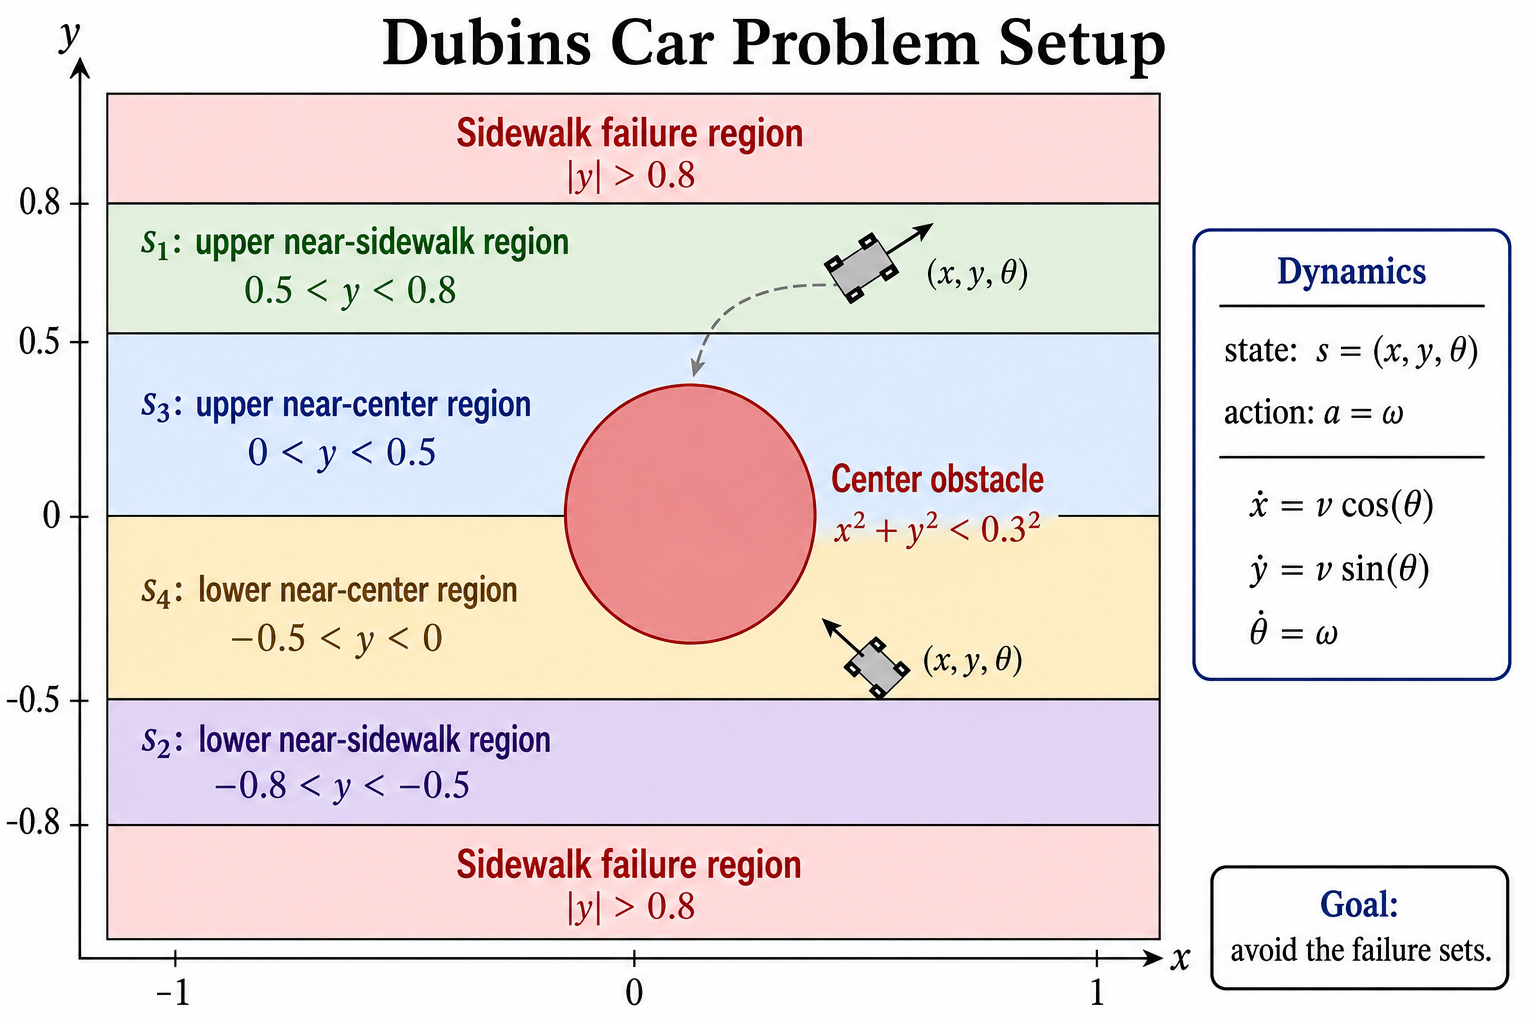

Set up environment with the new failure margin

In [4]:
import os
import sys
import pathlib
import types
os.environ.setdefault("MUJOCO_GL", "osmesa")
sys.path.insert(0, "/home/alina/projects/eais_hw2")
sys.path.insert(0, "/home/alina/projects/eais_hw2/dreamerv3-torch")
sys.path.insert(0, "/home/alina/projects/eais_hw2/safety_rl")

import numpy as np
import torch
import gym
import ruamel.yaml as yaml
from gym_reachability import gym_reachability

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
yaml = yaml.YAML(typ="safe", pure=True)
config_path = pathlib.Path('eais_hw2/configs.yaml').resolve()
args = types.SimpleNamespace(**yaml.load(config_path.read_text())['defaults'])

OBS_RADIUS = 0.3
SIDEWALK = 0.8

# sidewalk is preferred over center
# upper sidewalk is preferred over lower sidewalk
# upper safe region is preferred over lower safe region
W_CENTER_OBS = 3.0 # failure margin weight for center obstacle
W_LOWER_SW = 1.0 # failure margin weight for lower sidewalk
W_UPPER_SW = 1.0 # failure margin weight for upper sidewalk
W_LOWER_SAFE = 0.5
W_UPPER_SAFE = 1.0 # failure margin weight for upper safe region

env_name = "dubins_car_avoid-v1"
maxUpdates = args.maxUpdates
updateTimes = args.updateTimes
updatePeriod = int(maxUpdates / updateTimes)
updatePeriodHalf = int(updatePeriod / 2)
maxSteps = 25

env = gym.make(env_name, device=device, config=args, mode=args.mode,
               doneType=args.doneType, sample_inside_obs=True)
env.set_speed(args.speed)
env.set_constraint(radius=OBS_RADIUS)
env.set_radius_rotation(R_turn=args.speed/args.turnRate)
env.set_seed(args.randomSeed)

# define safety margin
# minimum of distance to center obstacle and distance to sidewalk
def safety_margin(state):
    state = np.asarray(state, dtype=float)
    x = float(state[0])
    y = float(state[1])
    l_center = np.linalg.norm(state[:2]) - OBS_RADIUS # distance to center obstacle
    l_sidewalk = SIDEWALK - abs(y) # distance to sidewalk
    margin = min(l_center, l_sidewalk)
    if margin < 0: # car is inside obstacle
        if l_center < 0: # car is inside center obstacle
            margin = l_center * W_CENTER_OBS
        else:
            if y < -SIDEWALK: # car is in lower sidewalk
                margin = l_sidewalk * W_LOWER_SW
            elif y > SIDEWALK: # car is in upper sidewalk
                margin = l_sidewalk * W_UPPER_SW
    else: # car is in safe region
        if y > 0:
            margin = margin * W_UPPER_SAFE
        else:
            margin = margin * W_LOWER_SAFE

    return margin

# set new safety margin for the environment
env.unwrapped.safety_margin = safety_margin

Env: mode-RA; doneType-toEnd; sample_inside_obs-True


Train DDQN on new safety margin

In [5]:
from RARL.DDQNSingleAvoid import DDQNSingleAvoid
from RARL.config import dqnConfig
from RARL.model import Model

outFolder = f"logs/experiments/car-DDQN/privileged_sidewalk_{W_CENTER_OBS}_{W_LOWER_SW}_{W_UPPER_SW}_{W_LOWER_SAFE}_{W_UPPER_SAFE}"
# outFolder = f"logs/experiments/car-DDQN/privileged_sidewalk_center_pref"

print("\n== Agent Information ==")

CONFIG = dqnConfig(
    DEVICE=device, ENV_NAME=env_name, SEED=args.randomSeed,
    MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, BATCH_SIZE=64,
    MEMORY_CAPACITY=args.memoryCapacity, ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, GAMMA=args.gamma, GAMMA_PERIOD=updatePeriod,
    GAMMA_END=0.9999, EPS_PERIOD=int(updatePeriod / 10), EPS_DECAY=0.7,
    EPS_RESET_PERIOD=updatePeriod, LR_C=args.learningRate,
    LR_C_PERIOD=updatePeriod, LR_C_DECAY=0.75, MAX_MODEL=50
)

# == AGENT ==
stateDim = env.state.shape[0]
actionNum = env.action_space.n
dimList = [stateDim] + list(CONFIG.ARCHITECTURE) + [actionNum]   
actionList = np.arange(actionNum) 
agent = DDQNSingleAvoid(
    CONFIG, actionNum, actionList, dimList=dimList, mode=args.mode,
    terminalType=args.terminalType
)
print("We want to use: {}, and Agent uses: {}".format(device, agent.device))
print("Critic is using cuda: ", next(agent.Q_network.parameters()).is_cuda)

# vmin = -2
# vmax = 2
# lossList = agent.initQ(
#     env, args.warmupIter, outFolder, num_warmup_samples=200, vmin=vmin,
#     vmax=vmax, plotFigure=args.plotFigure, storeFigure=args.storeFigure
# )
# print("\n== Training Information ==")
# trainRecords, trainProgress = agent.learn(
#     env, MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, warmupQ=False,
#     doneTerminate=True, vmin=vmin, vmax=vmax, showBool=False,
#     checkPeriod=args.checkPeriod, outFolder=outFolder,
#     plotFigure=args.plotFigure, storeFigure=args.storeFigure
# )
# print("Training complete")


== Agent Information ==
ModuleList(
  (0): Linear(in_features=3, out_features=100, bias=True)
  (1): Tanh()
  (2): Linear(in_features=100, out_features=100, bias=True)
  (3): Tanh()
  (4): Linear(in_features=100, out_features=3, bias=True)
  (5): Identity()
)
DDQN: mode-RA; terminalType-g
We want to use: cuda, and Agent uses: cuda
Critic is using cuda:  True


Learned BRT after 100000 steps

(Note: there's an embedded ground truth overlay in the DDQN's BRT plotting function, which does not apply to our sidewalk environment. I didn't want to modify the DDQN code file so I kept it that way.)

(Note: but the failure margin overlay for the central obstacle is correct)

Safety filter implementation

In [15]:
import numpy as np
from RARL.model import Model

EPS = 0.5
SAFE = True

# load trained Q network
MODEL_PATH = f"{outFolder}/model/Q-500000.pth"
print(f"Loading model from {MODEL_PATH}")
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"EPS (safety margin threshold): {EPS}")
stateDim = env.state.shape[0]
actionNum = env.action_space.n
dimList = [stateDim] + list(CONFIG.ARCHITECTURE) + [actionNum]   
actionList = np.arange(actionNum) 
Q_network = Model(dimList, "Tanh")
Q_network.load_state_dict(torch.load(MODEL_PATH, map_location=device))
Q_network.to(device)
Q_network.eval()

# define nominal policy (constant or random action)
def nominal_policy(type):
    if type == "constant":
        return 1  # always go straight
    elif type == "random":
        return np.random.choice(actionList)

# define safety filter
def filtered_action(policy_type, state):
    with torch.no_grad():
        q_values = Q_network(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)).squeeze(0)
    nominal_action = nominal_policy(policy_type)
    g_x = q_values[nominal_action].item()

    if g_x <= EPS: # unsafe, override with safe action
        return q_values.argmax().item(), True
    else: # safe, use nominal action
        return nominal_action, False

# get the value function g(x) for a given state     
def get_value(state):
    with torch.no_grad():
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        q_values = Q_network(state_tensor).squeeze(0)
        g_x = torch.max(q_values).item()
    return g_x

# sample a safe initial state that is some positive margin above the unsafe boundary
# sample an unsafe initial state that is some positive margin below the unsafe boundary
def sample_random_state(margin=0.1, safe=True):
    while True:
        xy = np.random.uniform(env.low[:2], env.high[:2] )
        th = np.random.uniform(0, 2 * np.pi)
        state = np.array([xy[0], xy[1], th], dtype=np.float32)
        g_x = get_value(state)
        if safe and g_x > margin:
            return state
        if not safe and g_x < -margin and env.safety_margin(state) > 0:
            return state
        
# rollout a trajectory using the nominal policy and safety filter
# starts from a safe initial state and terminates if it goes out of bounds or reach max_steps
# makes sure to collect trajectories that are long enough (at least max_steps // 4) for better visualization
# makes sure to collect trajectories in which the safety filter is active at some point
def rollout_trajectory(nominal_policy_type, max_steps=100, start_state=None):
    traj, filtered = [], []
    while len(traj) < max_steps // 4 or not any(filtered):
        traj, filtered = [], []
        state = sample_random_state(safe=SAFE) if start_state is None else np.asarray(start_state, dtype=np.float32)
        for _ in range(max_steps):
            if not env.car.check_within_bounds(state):
                break
            action, overriden = filtered_action(nominal_policy_type, state)
            state = env.car.integrate_forward(state, env.car.discrete_controls[action])
            traj.append(state)
            filtered.append(overriden)
    return np.array(traj), np.array(filtered)

Loading model from logs/experiments/car-DDQN/privileged_sidewalk_3.0_1.0_1.0_0.5_1.0/model/Q-500000.pth
Using device: cuda
EPS (safety margin threshold): 0.5


/tmp/ipykernel_256033/3573943554.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Q_network.load_state_dict(torch.load(MODEL_PATH, map_location=device))


In [11]:
# visualize trajectories
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.animation as anim
from matplotlib.patches import Circle
from IPython.display import HTML
import os

# draw a single trajectory
def draw_traj(ax, traj, filtered, t):
    ax.cla()
    # env.plot_failure_set(ax)
    env.plot_formatting(ax)

    # manually plot the failure set
    ax.add_patch(Circle((0,0), OBS_RADIUS, color="r", alpha=0.3))
    ax.axhspan(SIDEWALK, 1.1, color="r", alpha=0.15)
    ax.axhspan(-1.1, -SIDEWALK, color="r", alpha=0.15)

    t = min(t, len(traj) - 1)
    sub = traj[:t+1]

    traj_x = sub[:, 0]
    traj_y = sub[:, 1]
    ax.scatter(traj_x[0], traj_y[0], s=48, c="y", zorder=2)
    ax.plot(traj_x, traj_y, color="y", linewidth=2, zorder=2)

    cur_x, cur_y, th = traj[t]
    car_color = "orange" if filtered[t] else "r" # change car color when safety filter is active
    ax.scatter(cur_x, cur_y, s=80, c=car_color, zorder=3)
    ax.quiver(cur_x, cur_y, np.cos(th), np.sin(th), color=car_color, scale=15, zorder=3)

# generate video grid of trajectories for a given nominal policy type
def make_video_grid(policy_type, rows=2, cols=4, save_path=None, start_state=None):
    trajs = [[rollout_trajectory(policy_type, start_state=start_state) for _ in range(cols)] for _ in range(rows)]
    max_T = max(len(trajs[r][c][0]) for r in range(rows) for c in range(cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), squeeze=False)
    fig.suptitle(f"{policy_type} nominal policy, EPS={EPS}", fontsize=16)

    def update(t):
        for r in range(rows):
            for c in range(cols):
                traj, filtered = trajs[r][c]
                draw_traj(axes[r, c], traj, filtered, t)
        return []

    ani = anim.FuncAnimation(fig, update, frames=max_T, interval=200)
    if save_path is not None: # save to file
        writer = "pillow" if str(save_path).endswith(".gif") else "ffmpeg"
        ani.save(save_path, writer=writer, fps=5)
        plt.close(fig)
        print(f"saved video to {save_path}")
        return save_path
    else: # show in notebook
        html = ani.to_html5_video()
        plt.close(fig)
        return html

# # generate and display video grids for both nominal policy types
# for i in range(0, 64):
#     make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
#     make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))

# generate rollout video from custom initial state
from datetime import datetime
now = datetime.now()
dt = now.strftime("%y%m%H%M%S")
EPS = 0.0
x = 0.6
y = 0.3
theta = 1.18 * np.pi # heading is from 0 to 2 pi
st = np.array([x, y, np.mod(theta, 2 * np.pi)], dtype=np.float32)
make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/{dt}.gif"), start_state=st)

saved video to logs/experiments/car-DDQN/privileged_sidewalk_3.0_1.0_1.0_0.5_1.0/video/2606172132.gif


'logs/experiments/car-DDQN/privileged_sidewalk_3.0_1.0_1.0_0.5_1.0/video/2606172132.gif'

In [ ]:
EPS = 0.1
SAFE = True
outFolder = f"logs/experiments/car-DDQN/privileged_sidewalk_center_pref"
for i in range(0, 128):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))

EPS = 0.3
SAFE = True
for i in range(0, 128):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))

EPS = 0.5
SAFE = True
for i in range(0, 128):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))
outFolder = f"logs/experiments/car-DDQN/privileged_sidewalk_side_pref"

EPS = 0.3
SAFE = False
for i in range(128, 256):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))
outFolder = f"logs/experiments/car-DDQN/privileged_sidewalk_side_pref"

EPS = 0.3
SAFE = False
for i in range(128, 256):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))

EPS = 0.5
SAFE = False
for i in range(128, 256):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))

# load trained Q network
MODEL_PATH = f"{outFolder}/model/Q-1000000.pth"
print(f"Loading model from {MODEL_PATH}")
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"EPS (safety margin threshold): {EPS}")
stateDim = env.state.shape[0]
actionNum = env.action_space.n
dimList = [stateDim] + list(CONFIG.ARCHITECTURE) + [actionNum]   
actionList = np.arange(actionNum) 
Q_network = Model(dimList, "Tanh")
Q_network.load_state_dict(torch.load(MODEL_PATH, map_location=device))
Q_network.to(device)
Q_network.eval()

EPS = 0.1
SAFE = True
outFolder = f"logs/experiments/car-DDQN/privileged_sidewalk_side_pref"

for i in range(0, 128):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))

EPS = 0.3
SAFE = True

for i in range(0, 128):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))

EPS = 0.5
SAFE = True

for i in range(0, 128):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))

EPS = 0.3
SAFE = False

for i in range(128, 256):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))

EPS = 0.3
SAFE = False

for i in range(128, 256):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))

EPS = 0.5
SAFE = False

for i in range(128, 256):
    make_video_grid("constant", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/constant_eps={EPS}_{i}.gif"))
    make_video_grid("random", rows=1, cols=1, save_path=os.path.join(outFolder, f"video/random_eps={EPS}_{i}.gif"))

saved video to logs/experiments/car-DDQN/privileged_sidewalk_center_pref/video/constant_eps=0.1_0.gif
saved video to logs/experiments/car-DDQN/privileged_sidewalk_center_pref/video/random_eps=0.1_0.gif
saved video to logs/experiments/car-DDQN/privileged_sidewalk_center_pref/video/constant_eps=0.1_1.gif
saved video to logs/experiments/car-DDQN/privileged_sidewalk_center_pref/video/random_eps=0.1_1.gif
saved video to logs/experiments/car-DDQN/privileged_sidewalk_center_pref/video/constant_eps=0.1_2.gif
saved video to logs/experiments/car-DDQN/privileged_sidewalk_center_pref/video/random_eps=0.1_2.gif


In [13]:
# compare behaviors between two Q networks

# load trained Q network
outFolder1 = "logs/experiments/car-DDQN/privileged_sidewalk_3.0_1.0_1.0_0.5_1.0"
outFolder2 = "logs/experiments/car-DDQN/privileged_sidewalk_1.0_3.0_3.0_3.0_0.5"
MODEL_PATH_1 = f"{outFolder1}/model/Q-500000.pth"
MODEL_PATH_2 = f"{outFolder2}/model/Q-500000.pth"

print(f"Loading model from {MODEL_PATH_1}")
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"EPS (safety margin threshold): {EPS}")

stateDim = env.state.shape[0]
actionNum = env.action_space.n
dimList = [stateDim] + list(CONFIG.ARCHITECTURE) + [actionNum]   
actionList = np.arange(actionNum) 

Q_network1 = Model(dimList, "Tanh")
Q_network1.load_state_dict(torch.load(MODEL_PATH_1, map_location=device))
Q_network1.to(device)
Q_network1.eval()

print(f"Loading model from {MODEL_PATH_2}")
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"EPS (safety margin threshold): {EPS}")

Q_network2 = Model(dimList, "Tanh")
Q_network2.load_state_dict(torch.load(MODEL_PATH_2, map_location=device))
Q_network2.to(device)
Q_network2.eval()

Loading model from logs/experiments/car-DDQN/privileged_sidewalk_3.0_1.0_1.0_0.5_1.0/model/Q-500000.pth
Using device: cuda
EPS (safety margin threshold): 0.1
Loading model from logs/experiments/car-DDQN/privileged_sidewalk_1.0_3.0_3.0_3.0_0.5/model/Q-500000.pth
Using device: cuda
EPS (safety margin threshold): 0.1


/tmp/ipykernel_256033/68464854.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Q_network1.load_state_dict(torch.load(MODEL_PATH_1, map_location=device))
/tmp/ipykernel_

Model(
  (moduleList): ModuleList(
    (0): Linear(in_features=3, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=3, bias=True)
    (5): Identity()
  )
)

In [ ]:
import os
import numpy as np
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt, matplotlib.animation as anim
from IPython.display import HTML, display
from datetime import datetime

os.makedirs("comp_video", exist_ok=True)

def make_start_state(x, y, theta):
    return np.array([x, y, np.mod(theta, 2 * np.pi)], dtype=np.float32)

# one filtered rollout from a fixed start, using a specified Q network
def rollout_from(qnet, start_state, policy_type, max_steps=100):
    global Q_network
    saved, Q_network = Q_network, qnet
    try:
        state = np.asarray(start_state, dtype=np.float32)
        traj, filtered = [state], []
        for _ in range(max_steps):
            if not env.car.check_within_bounds(state):
                break
            action, overriden = filtered_action(policy_type, state)
            filtered.append(overriden)
            state = env.car.integrate_forward(state, env.car.discrete_controls[action])
            traj.append(state)
        filtered.append(filtered[-1] if filtered else False)
    finally:
        Q_network = saved
    return np.array(traj), np.array(filtered)

# side-by-side video of both models from the same start
def compare_models(start_state, policy_type="constant", labels=("model 1", "model 2"), save=True):
    traj1, filt1 = rollout_from(Q_network1, start_state, policy_type)
    traj2, filt2 = rollout_from(Q_network2, start_state, policy_type)
    rolls = [(traj1, filt1, labels[0]), (traj2, filt2, labels[1])]
    max_T = max(len(t) for t, _, _ in rolls)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    x0, y0, th0 = start_state
    fig.suptitle(f"{policy_type} nominal | start = ({x0:.2f}, {y0:.2f}, {th0:.2f})", fontsize=13)

    def update(t):
        for ax, (traj, filtered, lab) in zip(axes, rolls):
            draw_traj(ax, traj, filtered, t)
            ax.set_title(lab, fontsize=10)
        return []

    ani = anim.FuncAnimation(fig, update, frames=max_T, interval=200)
    if save:
        now = datetime.now()
        dt = now.strftime("%y%m%H%M%S")
        fname = f"logs/experiments/car-DDQN/comp_video/compare_{policy_type}_eps={EPS}_{dt}.gif"
        ani.save(fname, writer="pillow", fps=5)
        print("saved", fname)
    html = ani.to_html5_video()
    plt.close(fig)
    return HTML(html)

# compare both models from the same set of initial states
EPS = 0.1
SAFE = False
labels = (os.path.basename(outFolder1), os.path.basename(outFolder2))
starts = [sample_random_state(safe=SAFE) for _ in range(64)]
for x, y, theta in starts:
    compare_models(make_start_state(x, y, theta), policy_type="constant", labels=labels)

FileNotFoundError: [Errno 2] No such file or directory: 'logs/comp_video'